In [1]:
import os
import numpy as np
import argparse

from liblibra_core import *
from libra_py import units

import sys
import os

sys.path.append(os.path.abspath(".."))

from kcrpmd_utils.kcrpmdtst import KcrpmdTst
from kcrpmd_utils.kcrpmdmodel import gen_kcrpmd_bath_params, get_ABC

import matplotlib.pyplot as plt

plt.rcParams.update({            
    'figure.figsize': (4.0, 3.0),
    'figure.dpi': 150,           
    'figure.facecolor': 'white', 
    'figure.edgecolor': 'white', 
    'lines.linewidth': 2,        
    'axes.linewidth': 3,         
    'axes.labelsize': 19,        
    'axes.titlesize': 19,        
    'xtick.direction': 'in',     
    'xtick.top': True,           
    'ytick.direction': 'in',     
    'ytick.right': True,         
    'xtick.major.width': 1.5,    
    'ytick.major.width': 1.5,    
    'xtick.major.size': 4,       
    'ytick.major.size': 4,       
    'xtick.labelsize': 13.5,     
    'ytick.labelsize': 13.5,     
    'legend.fontsize': 11,       
    'legend.frameon': False,     
})                               



<frozen importlib._bootstrap>:228: RuntimeWarning: to-Python converter for std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:228: RuntimeWarning: to-Python converter for boost::python::detail::container_element<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, unsigned long, boost::python::detail::final_vector_derived_policies<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, false> > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:228: RuntimeWarning: to-Python converter for std::vector<std::vector<float, std::allocator<float> >, std::allocator<std::vector<float, std::allocator<float> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:228: RuntimeWar

In [2]:
###################################################
# ======= ASSIGNING PARAMETERS FOR SYSTEM ======= #
###################################################
T = 300.0 # Temperature in K
beta = units.hartree / (units.boltzmann * T)
a = 0.1 # KC-RPMD parameter a
b = 1000.0 # KC-RPMD parameter b
c = 1.0 # KC-RPMD parameter c

ms = 1836.0 # Mass of s
ws = 2.28e-3 # Frequency of s
s0 = -2.4 # Diabat 0 parabola minima
s1 = 2.4 # Diabat 1 parabola minima
eps = 0.0 # Diabat 0 to diabat 1 driving force

M = 1836.0 # Ohmic bath mass
wc = 2.28e-3 # Ohmic bath cutoff frequency
gam = 250.0 / (M * wc) # Ohmic bath friction coefficient
tauL = gam/(ws**2*ms) # Debye longitudinal relaxation time for Zusman rate later
wj, cj, mj = gen_kcrpmd_bath_params({"M":M, "wc":wc, "gam":gam, "f":12}) # Ohmic spectral density bath parameters

K0 = 1.0e-10 # Diabatic coupling constant/prefactor
mq = 5.0e4 # q coordinate mass
wq = 5.0e-4 # q coordinate frequency
#Dq = 1.0e-3 # q coordinate morse potential parameter
#(q0, Ea, leps) = (2.1, 6.65e-3, args.leps) # System C q coordinate double well parameters
#(Aq, Bq, Cq) = get_ABC(q0, leps, Ea) # Numerically computing Aq, Bq, Cq from q0, leps, Ea
#qhw = 1.0 # Hard wall potential location
#khw = 1.0e5 # Hard wall potential strength

###########################################################################################
# ======= NOW CALLING ON TST CODE TO COMPUTE FREE ENERGIES AND KC-RPMD PARAMETERS ======= #
###########################################################################################

# Defining Kq and Vq functions of system for TST code
Kq = lambda q: np.full_like(q, K0)
Vq = lambda q: 0.5 * mq * wq**2 * q**2

kcrpmd_tst = KcrpmdTst(beta, a, b, c, ms, ws, s0, s1, eps, Kq, Vq)
ydag = kcrpmd_tst.ydag
sdag = kcrpmd_tst.sdag
kcrpmd_tst.set_eta_my_gammay()

# Computing ground state free energy and KC-RPMD free energy (fully integrated)
#Fg = kcrpmd_tst.Fg(); FKC = kcrpmd_tst.F()

# Computing full fermi-golden rule rate saving to _sys_*/tst_data (no hardwall influence)
#kGR_full = kcrpmd_tst.kGR()

# Coordinate arrays used in numerical integration and plotting for later
#s_arr = kcrpmd_tst.s_array()
#q_arr = kcrpmd_tst.q_array()
#y_arr = kcrpmd_tst.y_array()

# Now we calculate absolutely everything that might be useful later
# Hardwall influence if it's turned on, sys C only

#Phw = np.exp(-beta * (kcrpmd_tst.Fg() - Fg)) # Hardwall potential probability from 0 to 1
#Fsq = kcrpmd_tst.Vg(s_arr, q_arr) # Adiabatic free energy along s and q
#Fsdag = kcrpmd_tst.Fgs(np.array([sdag])) # Adiabatic free energy at sdagger
#Fsdagq = kcrpmd_tst.Vg(np.array([sdag]), q_arr) # Adiabatic free energy along q at sdagger
#Psdagq = np.exp(-beta * (Fsdagq - Fsdag))[:,0] # Adiabatic probability along q at sdagger
#kGR = kcrpmd_tst.kGR() # Fermi-golden rule rate
#kZUS = kcrpmd_tst.kZUS(tauL) # Zusman rate
#ktsts = kcrpmd_tst.kBO() # Adiabatic TST rate along s


In [12]:
gam = 250.0 / (M * wc) # Ohmic bath friction coefficient
tauL = gam/(ws**2*ms) # Debye longitudinal relaxation time for Zusman rate later

K0_arr = np.linspace(10**(-2.1), 10**(1.1), 50)/beta
kGR_arr = np.zeros_like(K0_arr)
kZUS_arr = np.zeros_like(K0_arr)

for i, K in enumerate(K0_arr):
    kcrpmd_tst.Kq = lambda q: np.full_like(q, K)
    kGR_arr[i] = kcrpmd_tst.kGR() # Fermi-golden rule rate
    kZUS_arr[i] = kcrpmd_tst.kZUS(tauL) # Zusman rate

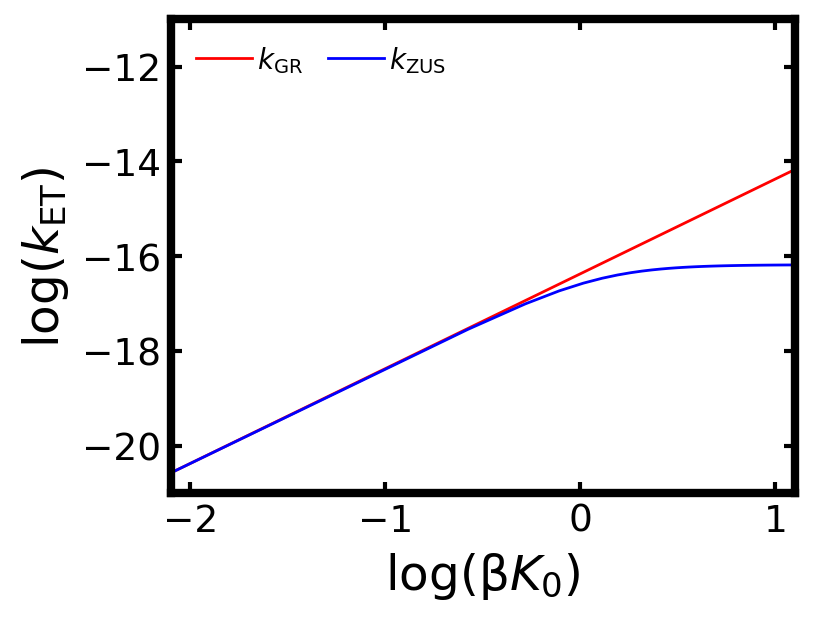

In [13]:

fig, ax = plt.subplots(dpi=200)
ax.plot(np.log10(beta * K0_arr), np.log10(kGR_arr), linewidth=1, color='r', label=r'$k_\mathrm{GR}$')
ax.plot(np.log10(beta * K0_arr), np.log10(kZUS_arr), linewidth=1, color='b', label=r'$k_\mathrm{ZUS}$')
ax.set_xlim(-2.1,1.1)
ax.set_ylim(-21.0,-11.0)
ax.set_xticks([-2, -1, 0, 1])
ax.set_yticks([-20, -18, -16, -14, -12])
ax.set_xlabel(r"log(β$K_0$)", fontsize = 17.5)
ax.set_ylabel(r"log($k_{\mathrm{ET}}$)", fontsize = 17.5)
ax.set_title("")
ax.legend(ncol=3, fontsize=10, loc='upper left', handletextpad=0.2,  columnspacing=0.9)

plt.subplots_adjust(left=0.20, right=0.98, top=0.98, bottom=0.19)
plt.savefig('fig4.5.png')
#plt.show()


In [11]:
ms*ws

4.18608